# Diurnal Cycle over Wangara, Australia: Time–Height Diagnostics

*Last updated: May 2026*

This notebook visualizes the JAX-ALFA simulation of the Wangara Day 33–34 diurnal cycle. The simulation covers a full 24-hour period from 0900 LST 16 August 1967 to 0900 LST 17 August 1967.

| Quantity | Value                                                                                             |
| --- |---------------------------------------------------------------------------------------------------|
| Domain | 5000 m × 5000 m × 2000 m                                                                          |
| Reference grid | $128^3$                                                                                           |
| Roughness length | $z_0 = 0.01$ m                                                                                    |
| Screen temperature height | $z_T = 1.2$ m                                                                                     |
| Geostrophic wind | time- and height-varying ($\texttt{optGeoWind}=1$)                                                |
| SGS model | LASDD-SM ($\texttt{optSgs}=1$); run matrix uses LASDD-SM, LASDD-WL, LAD-SM, LAD-WL with SP and DP |

Figures show **time–height** contour plots of mean wind, potential temperature,
resolved variances, and total (resolved + SGS) fluxes.

## Setup

In [1]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

### Output directory and case configuration

In [2]:
from pathlib import Path
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir = find_repo_root()
RunDir    = BaseDir / 'examples_A6000ada/DC_Wangara/runs/128x128x128_LASDD_SM_SP'
OutputDir = RunDir / 'output'

# Read case parameters directly from Config.py so the notebook stays in sync.
_cfg = {}
exec((RunDir / 'Config.py').read_text(), _cfg)

nz                 = int(_cfg['nz'])
l_z                = float(_cfg['l_z'])
dt                 = float(_cfg['dt'])
SimTime            = float(_cfg['SimTime'])
T_0                = float(_cfg['T_0'])
optGeoWind         = int(_cfg.get('optGeoWind', 0))
optSgs             = int(_cfg['optSgs'])
OutputInterval_sec = float(_cfg['OutputInterval_sec'])

# LST offset: simulation t=0 corresponds to 0900 LST.
LST_offset = 9.0    # hours

print('BaseDir:', BaseDir)
print('RunDir: ', RunDir)
print(f'nz={nz}, l_z={l_z:g} m, dt={dt:g} s, OutputInterval={OutputInterval_sec:g} s')
print(f'optGeoWind={optGeoWind}, optSgs={optSgs}')

BaseDir: /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1
RunDir:  /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/examples_A6000ada/DC_Wangara/runs/128x128x128_LASDD_SM_SP
nz=128, l_z=2000 m, dt=0.5 s, OutputInterval=60 s
optGeoWind=1, optSgs=1


### Vertical grid

In [3]:
dz = l_z / (nz - 1)

# Half levels — U, V, TH, u2, v2, TH2
z = np.array([(k + 0.5) * dz for k in range(nz)])

# Full levels — w, uw, vw, wTH, txz, tyz, qz, w2
z_w = np.array([k * dz for k in range(nz)])

print(f'dz = {dz:.3f} m,  z[0] = {z[0]:.3f} m,  z[-1] = {z[-1]:.3f} m')

dz = 15.748 m,  z[0] = 7.874 m,  z[-1] = 2007.874 m


### Load output files

In [4]:
stat_files = sorted(
    glob.glob(str(OutputDir / 'ALFA_Statistics_Iteration_*.npz')),
    key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
)
n_files = len(stat_files)
missing_stats = (n_files == 0)
print(f'Found {n_files} output files in {OutputDir}')

if missing_stats:
    raise FileNotFoundError(
        f'No statistics files found in {OutputDir}. Run the Wangara case first; '
        'the notebook expects ALFA_Statistics_Iteration_*.npz files.'
    )

Found 1440 output files in /Users/sukantabasu/Dropbox/Codes/LES/JAX-ALFA/JAXALFA0.1/examples_A6000ada/DC_Wangara/runs/128x128x128_LASDD_SM_SP/output


In [5]:
# Build time axis from file iteration numbers.
if missing_stats:
    t_hours = np.array([0.0, SimTime / 3600.0])
else:
    iterations = np.array([
        int(re.search(r'Iteration_(\d+)', f).group(1)) for f in stat_files
    ])
    t_hours = iterations * dt / 3600.0          # simulation time (h)

LST = t_hours + LST_offset                      # Local Standard Time (h)

print(f'Time range: {t_hours[0]:.3f} - {t_hours[-1]:.2f} h  '
      f'(LST {LST[0]:.1f} - {LST[-1]:.1f} h)')


Time range: 0.017 - 24.00 h  (LST 9.0 - 33.0 h)


In [6]:
# Allocate (n_files, nz) arrays for all quantities.
U   = np.zeros((n_files, nz))
V   = np.zeros((n_files, nz))
TH  = np.zeros((n_files, nz))
u2  = np.zeros((n_files, nz))
v2  = np.zeros((n_files, nz))
w2  = np.zeros((n_files, nz))
TH2 = np.zeros((n_files, nz))
uw  = np.zeros((n_files, nz))
vw  = np.zeros((n_files, nz))
wTH = np.zeros((n_files, nz))
txz = np.zeros((n_files, nz))
tyz = np.zeros((n_files, nz))
qz  = np.zeros((n_files, nz))
ustar   = np.zeros(n_files)
qz_sfc  = np.zeros(n_files)

required = ['U', 'V', 'TH', 'u2', 'v2', 'w2', 'TH2',
            'uw', 'vw', 'wTH', 'txz', 'tyz', 'qz', 'ustar', 'qz_sfc']

if missing_stats:
    for arr in [U, V, TH, u2, v2, w2, TH2, uw, vw, wTH, txz, tyz, qz]:
        arr[:] = np.nan
    ustar[:] = np.nan
    qz_sfc[:] = np.nan

for i, f in enumerate(stat_files):
    with np.load(f) as d:
        missing = [k for k in required if k not in d]
        if missing:
            raise KeyError(f'{f} is missing arrays: {missing}')

        U[i]   = d['U']
        V[i]   = d['V']
        TH[i]  = d['TH']
        u2[i]  = d['u2']
        v2[i]  = d['v2']
        w2[i]  = d['w2']
        TH2[i] = d['TH2']
        uw[i]  = d['uw']
        vw[i]  = d['vw']
        wTH[i] = d['wTH']
        txz[i] = d['txz']
        tyz[i] = d['tyz']
        qz[i]  = d['qz']
        ustar[i]  = np.asarray(d['ustar']).mean()
        qz_sfc[i] = np.asarray(d['qz_sfc']).mean()

# Total (resolved + SGS) vertical fluxes.
uw_tot  = uw  + txz
vw_tot  = vw  + tyz
wTH_tot = wTH + qz

print('Data loaded.')

Data loaded.


### Plot style

In [7]:
plt.rcParams.update({
    'text.usetex'    : False,
    'font.size'      : 13,
    'axes.labelsize' : 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# Height limit for all panels (m).
z_max = 1500.0

# LST tick positions every 3 hours.
lst_ticks = np.arange(9, 34, 3)

def th_plot(ax, LST, z_axis, field, cmap, label, z_max=z_max):
    """Standard time-height pcolormesh helper."""
    pc = ax.pcolormesh(LST, z_axis, field.T,
                       cmap=cmap, shading='auto')
    cb = plt.colorbar(pc, ax=ax, pad=0.02)
    cb.set_label(label)
    ax.set_xlabel(r'LST (h)')
    ax.set_ylabel(r'$z$ (m)')
    ax.set_ylim(0, z_max)
    ax.set_xticks(lst_ticks)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    return pc

def symm_limits(data):
    """Return vmin/vmax centred on zero for a diverging colormap."""
    amax = np.nanmax(np.abs(data))
    return -amax, amax

## Mean Wind Components

Time–height evolution of the planar-mean zonal ($U$) and meridional ($V$) wind.

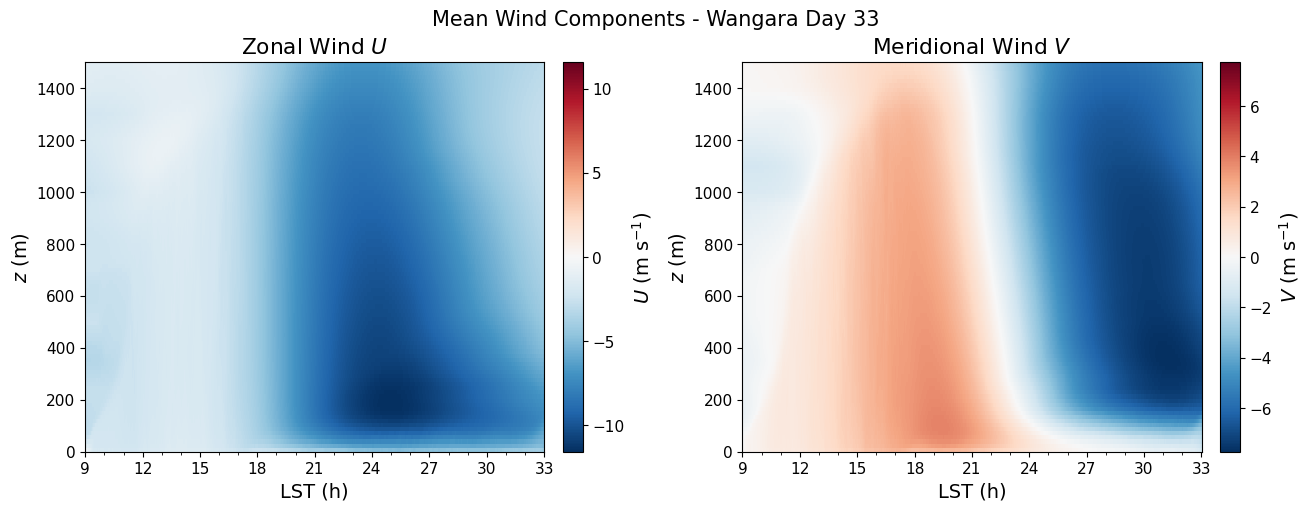

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

pc = th_plot(axs[0], LST, z, U, 'RdBu_r', r'$U$ (m s$^{-1}$)')
pc.set_clim(*symm_limits(U[:, z <= z_max]))
axs[0].set_title(r'Zonal Wind $U$')

pc = th_plot(axs[1], LST, z, V, 'RdBu_r', r'$V$ (m s$^{-1}$)')
pc.set_clim(*symm_limits(V[:, z <= z_max]))
axs[1].set_title(r'Meridional Wind $V$')

fig.suptitle('Mean Wind Components - Wangara Day 33', fontsize=15)
plt.show()

## Mean Potential Temperature

The diurnal heating and nocturnal cooling are clearly visible.

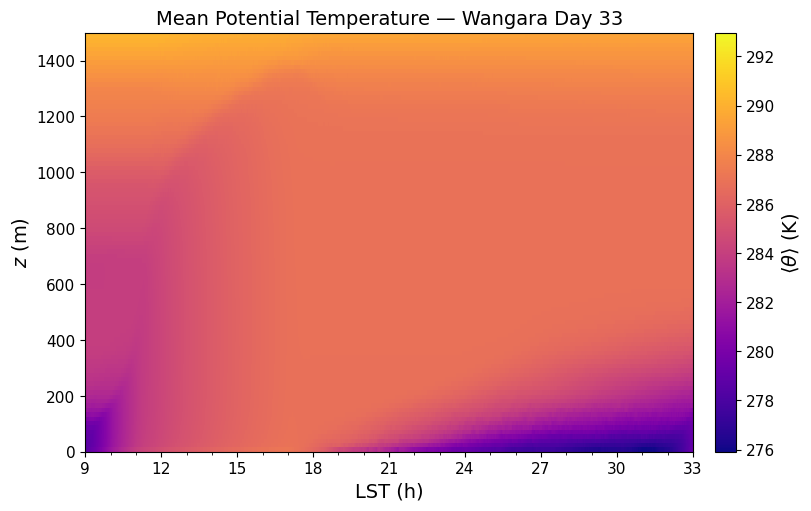

In [9]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

th_plot(ax, LST, z, TH, 'plasma', r'$\langle\theta\rangle$ (K)')
ax.set_title(r'Mean Potential Temperature — Wangara Day 33', fontsize=14)
plt.show()

## Resolved Velocity Variances

The resolved turbulent kinetic energy components; $\sigma_w^2$ is on full levels.

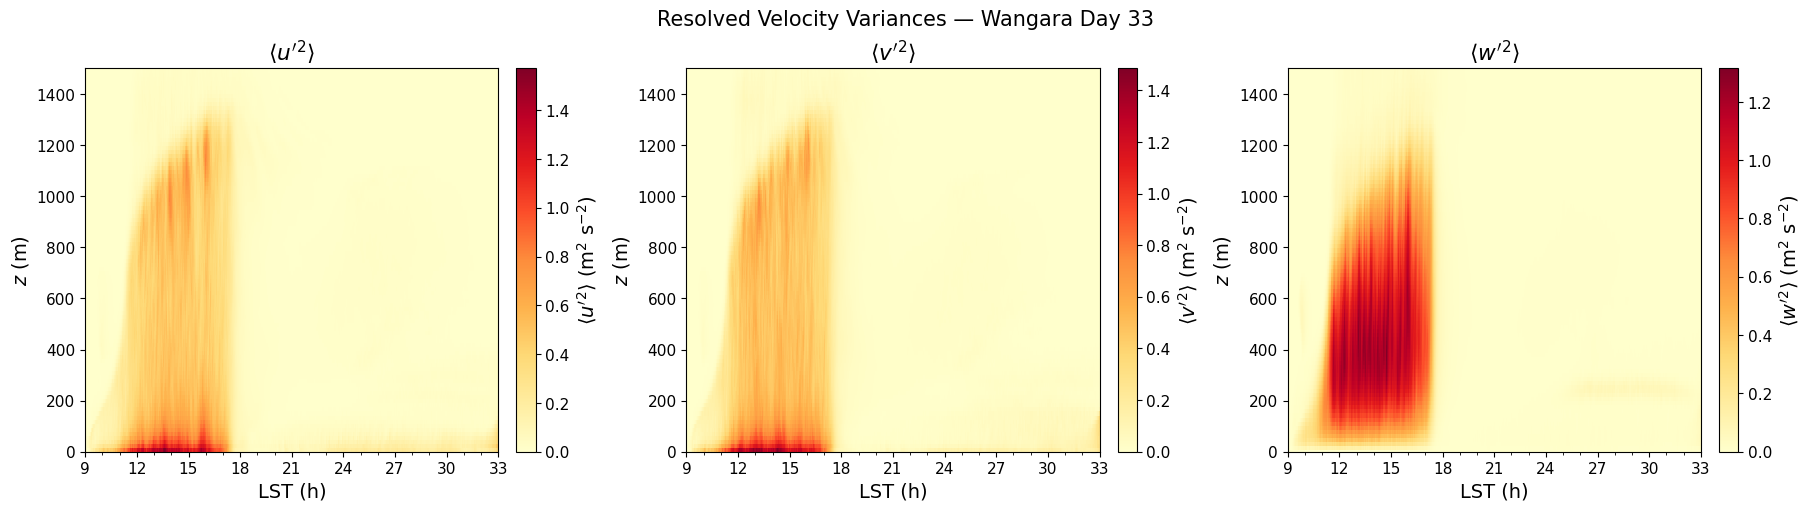

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

th_plot(axs[0], LST, z,   u2, 'YlOrRd', r"$\langle u'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[0].set_title(r"$\langle u'^2 \rangle$")

th_plot(axs[1], LST, z,   v2, 'YlOrRd', r"$\langle v'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[1].set_title(r"$\langle v'^2 \rangle$")

th_plot(axs[2], LST, z_w, w2, 'YlOrRd', r"$\langle w'^2 \rangle$ (m$^2$ s$^{-2}$)")
axs[2].set_title(r"$\langle w'^2 \rangle$")

fig.suptitle('Resolved Velocity Variances — Wangara Day 33', fontsize=15)
plt.show()

## Potential Temperature Variance

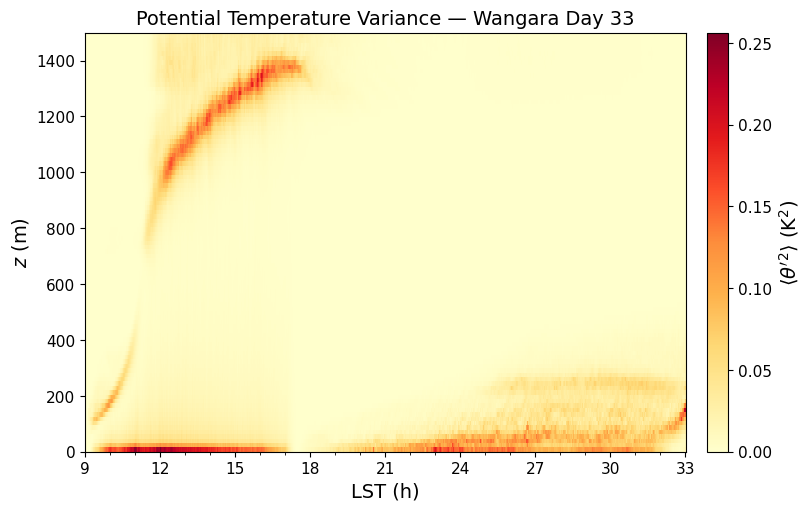

In [11]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

th_plot(ax, LST, z, TH2, 'YlOrRd', r"$\langle\theta'^2\rangle$ (K$^2$)")
ax.set_title(r"Potential Temperature Variance — Wangara Day 33", fontsize=14)
plt.show()

## Total Momentum Fluxes (Resolved + SGS)

$$\langle u'w' \rangle_{\mathrm{tot}} = \langle u'w' \rangle + \tau_{xz}, \qquad
  \langle v'w' \rangle_{\mathrm{tot}} = \langle v'w' \rangle + \tau_{yz}$$

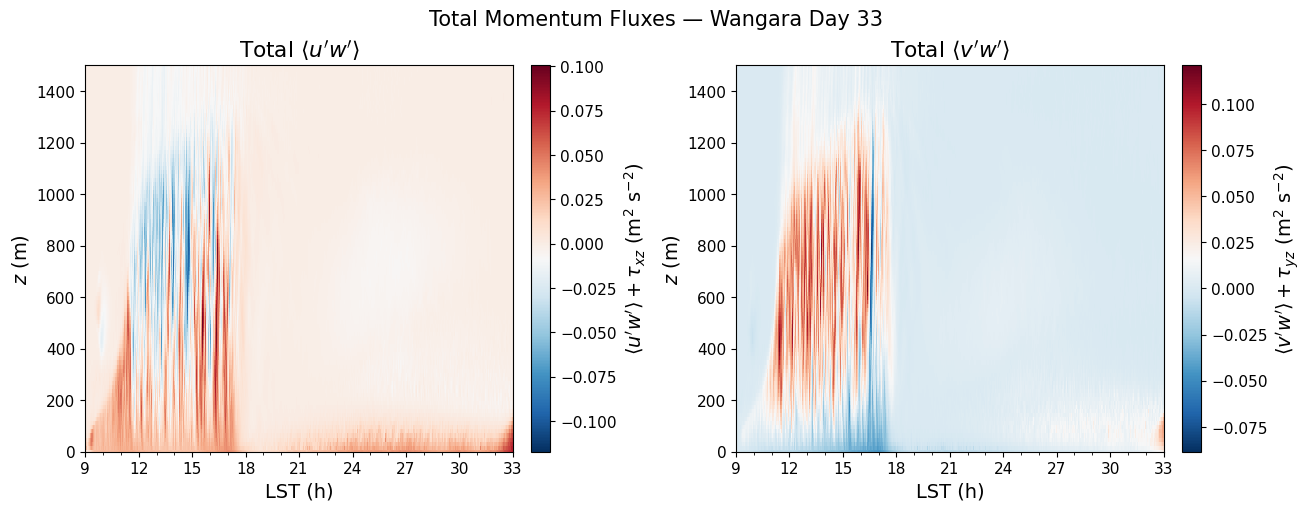

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

th_plot(axs[0], LST, z_w, uw_tot, 'RdBu_r',
        r"$\langle u'w'\rangle + \tau_{xz}$ (m$^2$ s$^{-2}$)")
axs[0].set_title(r"Total $\langle u'w' \rangle$")

th_plot(axs[1], LST, z_w, vw_tot, 'RdBu_r',
        r"$\langle v'w'\rangle + \tau_{yz}$ (m$^2$ s$^{-2}$)")
axs[1].set_title(r"Total $\langle v'w' \rangle$")

fig.suptitle('Total Momentum Fluxes — Wangara Day 33', fontsize=15)
plt.show()

## Total Heat Flux (Resolved + SGS)

$$\langle w'\theta' \rangle_{\mathrm{tot}} = \langle w'\theta' \rangle + q_z$$

Positive during the convective daytime hours, negative during the nocturnal stable phase.

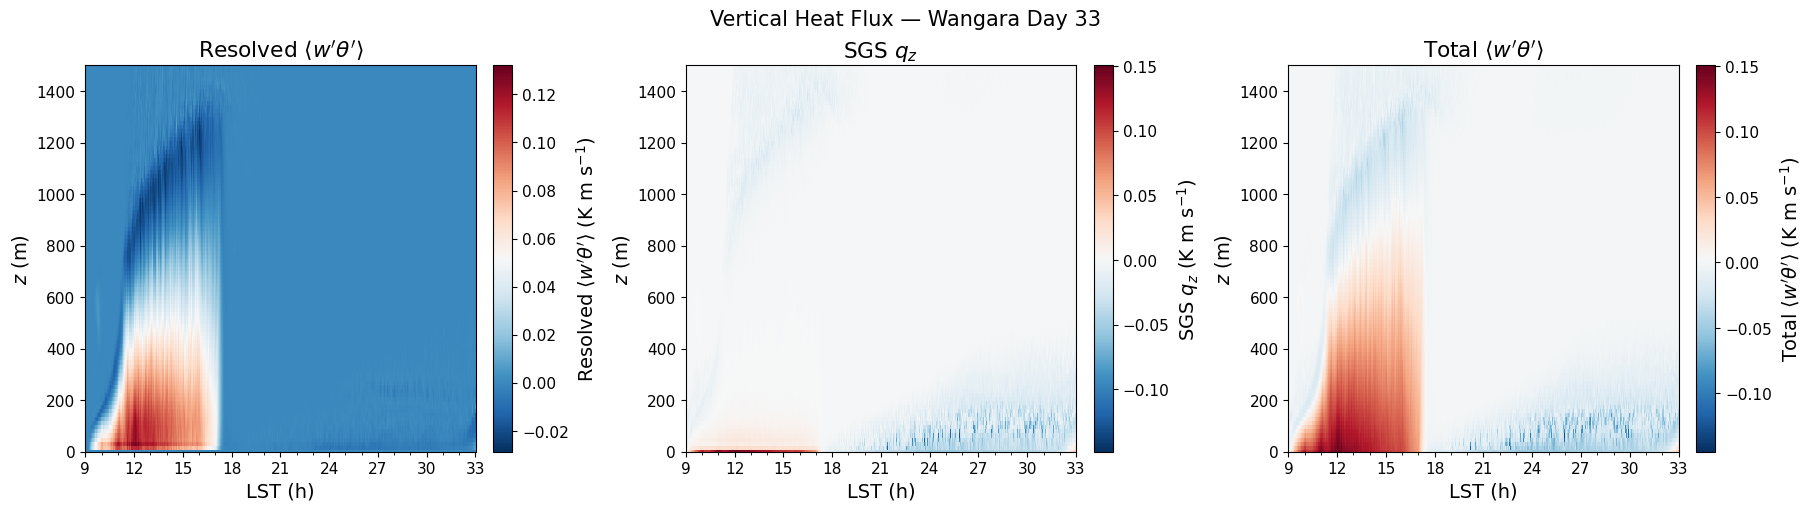

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

th_plot(axs[0], LST, z_w, wTH,     'RdBu_r',
        r"Resolved $\langle w'\theta'\rangle$ (K m s$^{-1}$)")
axs[0].set_title(r"Resolved $\langle w'\theta' \rangle$")

th_plot(axs[1], LST, z_w, qz,      'RdBu_r',
        r"SGS $q_z$ (K m s$^{-1}$)")
axs[1].set_title(r"SGS $q_z$")

th_plot(axs[2], LST, z_w, wTH_tot, 'RdBu_r',
        r"Total $\langle w'\theta'\rangle$ (K m s$^{-1}$)")
axs[2].set_title(r"Total $\langle w'\theta' \rangle$")

fig.suptitle('Vertical Heat Flux — Wangara Day 33', fontsize=15)
plt.show()

## Surface Time Series

Evolution of friction velocity $u_*$ and surface sensible heat flux $\overline{w'\theta'}_s$ throughout the diurnal cycle.

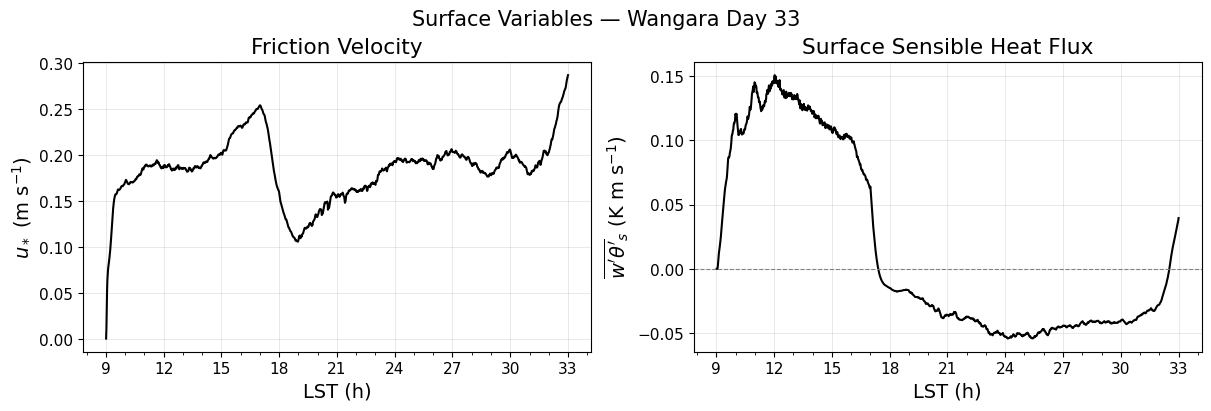

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axs[0].plot(LST, ustar, 'k', linewidth=1.5)
axs[0].set_xlabel(r'LST (h)')
axs[0].set_ylabel(r'$u_*$ (m s$^{-1}$)')
axs[0].set_title(r'Friction Velocity')
axs[0].set_xticks(lst_ticks)
axs[0].xaxis.set_minor_locator(ticker.MultipleLocator(1))
axs[0].grid(True, which='major', alpha=0.4)

axs[1].plot(LST, qz_sfc, 'k', linewidth=1.5)
axs[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axs[1].set_xlabel(r'LST (h)')
axs[1].set_ylabel(r"$\overline{w'\theta'}_s$ (K m s$^{-1}$)")
axs[1].set_title(r'Surface Sensible Heat Flux')
axs[1].set_xticks(lst_ticks)
axs[1].xaxis.set_minor_locator(ticker.MultipleLocator(1))
axs[1].grid(True, which='major', alpha=0.4)

fig.suptitle('Surface Variables — Wangara Day 33', fontsize=15)
plt.show()